In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

DATA_DIR   = r'D:\Tseng\圍棋\singletrials_timewindows'
BANDS      = ['Alpha', 'Beta', 'Delta', 'Gamma', 'Theta']
PARIETAL_CH = ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']

time_vals = [x / 10 for x in range(5, 195, 5)]
TIME_COLS = []
for v in time_vals:
    int_part = int(v)
    dec_part = round((v - int_part) * 10)
    TIME_COLS.append(f'T_{int_part}_{dec_part}s')

print('時間點欄位數:', len(TIME_COLS))   # 38
print('特徵維度: 38 × 5 bands =', len(TIME_COLS) * 5)

時間點欄位數: 38
特徵維度: 38 × 5 bands = 190


In [9]:
# ── 載入五個頻帶 CSV（全部 group 都讀進來）──
dfs = {}
for band in BANDS:
    dfs[band] = pd.read_csv(f'{DATA_DIR}\\Original_{band}.csv')
print('載入完成')

載入完成


In [10]:
# ── 前處理函式（支援任意 group）──
def preprocess_group(dfs, group):
    """
    回傳 X (n_trials, 190) 和 y (n_trials,) RT1_ms
    index = (SubjectID, Session, Epoch)
    """
    band_feats = {}
    rt_ref = None

    for band in BANDS:
        df = dfs[band]

        # 篩 group + Parietal
        df_g = df[(df['Group'] == group) &
                  (df['Channel'].isin(PARIETAL_CH))].copy()

        # RT1_ms 轉數值，移除無效 trial
        df_g['RT1_ms'] = pd.to_numeric(df_g['RT1_ms'], errors='coerce')
        bad = df_g[df_g['RT1_ms'].isna()][['SubjectID','Session','Epoch']].drop_duplicates()
        if len(bad):
            print(f'[{group}/{band}] 移除 {len(bad)} 筆無效 RT trial')
            df_g = df_g[~df_g.set_index(['SubjectID','Session','Epoch']).index.isin(
                bad.set_index(['SubjectID','Session','Epoch']).index)]

        grp = df_g.groupby(['SubjectID','Session','Epoch'])
        avg = grp[TIME_COLS].mean()
        rt  = grp['RT1_ms'].first()

        # sum=1 標準化
        avg_norm = avg.div(avg.sum(axis=1), axis=0)
        avg_norm.columns = [f'{band}_{c}' for c in TIME_COLS]

        band_feats[band] = avg_norm

        if rt_ref is None:
            rt_ref = rt
        else:
            assert avg_norm.index.equals(rt_ref.index), f'{band} index 不一致'

    X = pd.concat([band_feats[b] for b in BANDS], axis=1)
    y = rt_ref.rename('RT1_ms')
    print(f'[{group}] X={X.shape}  y={y.shape}  RT 範圍: {y.min():.0f}~{y.max():.0f} ms')
    return X, y


X_master,  y_master  = preprocess_group(dfs, 'master')
X_amateur, y_amateur = preprocess_group(dfs, 'amateur')
X_prof,    y_prof    = preprocess_group(dfs, 'prof')

[master] X=(1857, 190)  y=(1857,)  RT 範圍: 1232~58962 ms
[amateur/Alpha] 移除 64 筆無效 RT trial
[amateur/Beta] 移除 64 筆無效 RT trial
[amateur/Delta] 移除 64 筆無效 RT trial
[amateur/Gamma] 移除 64 筆無效 RT trial
[amateur/Theta] 移除 64 筆無效 RT trial
[amateur] X=(2396, 190)  y=(2396,)  RT 範圍: 1570~59320 ms
[prof] X=(719, 190)  y=(719,)  RT 範圍: 2024~58792 ms


In [11]:
# ── 在 Master 上訓練 SVR，預測 Amateur & Prof ──
#
# 訓練策略：用全部 master trials 訓練（因為 amateur/prof 是完全獨立的 test set）
# 若要評估 master 自身的泛化能力，下一個 cell 另做 master 內部 LOSO

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_master.values)
y_tr = y_master.values

svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=500)
svr.fit(X_tr, y_tr)
print('SVR 訓練完成（C=10, gamma=scale, epsilon=500）')

# 預測
def predict_and_report(name, X_raw, y_true):
    X_s = scaler.transform(X_raw.values)
    y_pred = svr.predict(X_s)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    pr, pp = pearsonr(y_true, y_pred)
    sr, sp = spearmanr(y_true, y_pred)

    print(f'\n[{name}]  N={len(y_true)}')
    print(f'  MAE   = {mae:.1f} ms')
    print(f'  RMSE  = {rmse:.1f} ms')
    print(f'  R²    = {r2:.4f}')
    print(f'  Pearson  r={pr:.4f}  p={pp:.4f}')
    print(f'  Spearman r={sr:.4f}  p={sp:.4f}')
    return y_pred

pred_amateur = predict_and_report('Amateur', X_amateur, y_amateur.values)
pred_prof    = predict_and_report('Prof',    X_prof,    y_prof.values)

SVR 訓練完成（C=10, gamma=scale, epsilon=500）

[Amateur]  N=2396
  MAE   = 13544.6 ms
  RMSE  = 17314.0 ms
  R²    = -0.2211
  Pearson  r=0.2148  p=0.0000
  Spearman r=0.2375  p=0.0000

[Prof]  N=719
  MAE   = 11146.2 ms
  RMSE  = 14575.1 ms
  R²    = -0.0780
  Pearson  r=0.4077  p=0.0000
  Spearman r=0.4432  p=0.0000


In [12]:
# ── Master 內部 LOSO（Leave-One-Subject-Out）自我評估 ──
# 確認模型在 master 本身的泛化能力

subject_col = X_master.index.get_level_values('SubjectID')
unique_subs = subject_col.unique()

loso_pred, loso_true = [], []
for sub in unique_subs:
    tr_mask = subject_col != sub
    te_mask = subject_col == sub

    X_tr_l = X_master.values[tr_mask]
    y_tr_l = y_master.values[tr_mask]
    X_te_l = X_master.values[te_mask]
    y_te_l = y_master.values[te_mask]

    sc_l = StandardScaler()
    X_tr_l = sc_l.fit_transform(X_tr_l)
    X_te_l = sc_l.transform(X_te_l)

    svr_l = SVR(kernel='rbf', C=10, gamma='scale', epsilon=500)
    svr_l.fit(X_tr_l, y_tr_l)
    loso_pred.extend(svr_l.predict(X_te_l))
    loso_true.extend(y_te_l)

loso_pred = np.array(loso_pred)
loso_true = np.array(loso_true)

mae_l  = mean_absolute_error(loso_true, loso_pred)
rmse_l = np.sqrt(mean_squared_error(loso_true, loso_pred))
r2_l   = r2_score(loso_true, loso_pred)
pr_l, pp_l = pearsonr(loso_true, loso_pred)
sr_l, sp_l = spearmanr(loso_true, loso_pred)

print('[Master LOSO]')
print(f'  MAE   = {mae_l:.1f} ms')
print(f'  RMSE  = {rmse_l:.1f} ms')
print(f'  R²    = {r2_l:.4f}')
print(f'  Pearson  r={pr_l:.4f}  p={pp_l:.4f}')
print(f'  Spearman r={sr_l:.4f}  p={sp_l:.4f}')

[Master LOSO]
  MAE   = 12941.4 ms
  RMSE  = 16391.6 ms
  R²    = -0.0524
  Pearson  r=-0.3632  p=0.0000
  Spearman r=-0.3316  p=0.0000


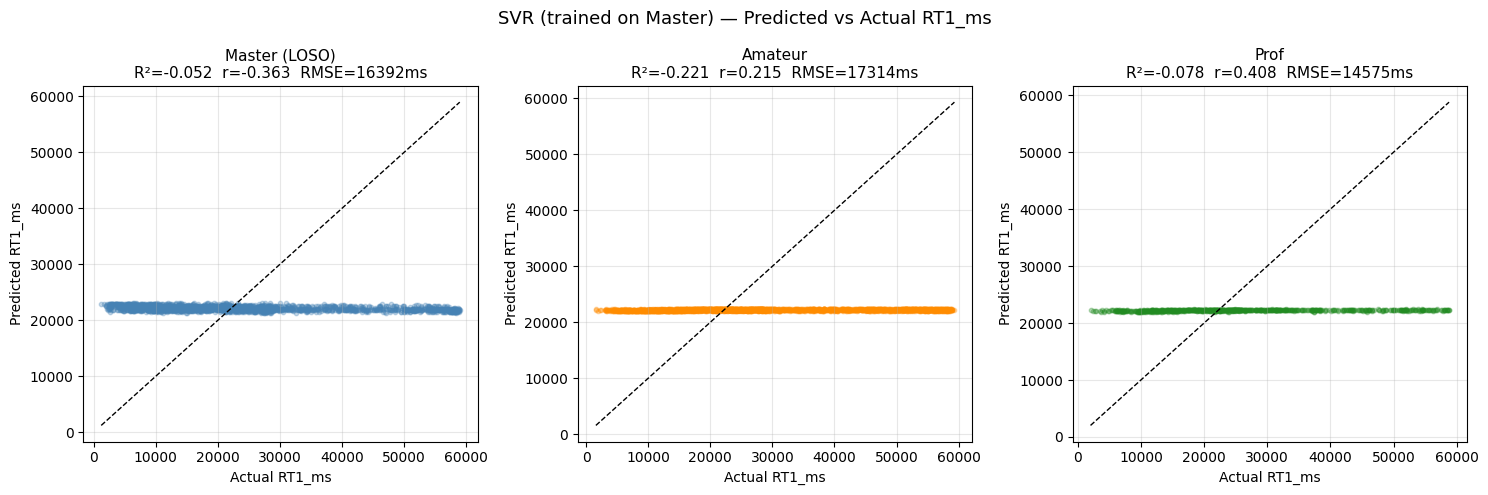

In [13]:
# ── 視覺化：Predicted vs Actual（三個群體）──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

groups_info = [
    ('Master (LOSO)', loso_true, loso_pred, 'steelblue'),
    ('Amateur',       y_amateur.values, pred_amateur, 'darkorange'),
    ('Prof',          y_prof.values,    pred_prof,    'forestgreen'),
]

for ax, (name, yt, yp, color) in zip(axes, groups_info):
    ax.scatter(yt, yp, alpha=0.3, s=10, color=color)
    lim_min = min(yt.min(), yp.min())
    lim_max = max(yt.max(), yp.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1)

    pr, _ = pearsonr(yt, yp)
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    r2    = r2_score(yt, yp)
    ax.set_title(f'{name}\nR²={r2:.3f}  r={pr:.3f}  RMSE={rmse:.0f}ms', fontsize=11)
    ax.set_xlabel('Actual RT1_ms')
    ax.set_ylabel('Predicted RT1_ms')
    ax.grid(alpha=0.3)

plt.suptitle('SVR (trained on Master) — Predicted vs Actual RT1_ms', fontsize=13)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\svr_rt_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Per-session SVR: train on Master, predict Amateur & Prof ──
SESSIONS = ['ss01', 'ss02', 'ss03']

# X_master / X_amateur / X_prof have MultiIndex (SubjectID, Session, Epoch)
results_ss = {}

for ss in SESSIONS:
    print(f'\n====== {ss} ======')

    m_mask = X_master.index.get_level_values('Session') == ss
    a_mask = X_amateur.index.get_level_values('Session') == ss
    p_mask = X_prof.index.get_level_values('Session') == ss

    X_tr = X_master.values[m_mask]
    y_tr = y_master.values[m_mask]
    print(f'  Master train: {len(X_tr)} trials  RT={y_tr.min():.0f}~{y_tr.max():.0f} ms')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=500)
    svr.fit(X_tr_s, y_tr)

    results_ss[ss] = {}
    for name, X_raw, y_true, mask in [
        ('amateur', X_amateur, y_amateur, a_mask),
        ('prof',    X_prof,    y_prof,    p_mask),
    ]:
        X_te   = X_raw.values[mask]
        y_te   = y_true.values[mask]
        y_pred = svr.predict(scaler.transform(X_te))

        pr, pp = pearsonr(y_te, y_pred)
        sr, sp = spearmanr(y_te, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_te, y_pred))

        results_ss[ss][name] = {
            'y_true': y_te, 'y_pred': y_pred,
            'pearson': pr, 'pearson_p': pp,
            'spearman': sr, 'spearman_p': sp,
            'rmse': rmse,
        }
        print(f'  [{name}] N={len(y_te)}  '
              f'Pearson r={pr:.4f}(p={pp:.4f})  '
              f'Spearman r={sr:.4f}(p={sp:.4f})  '
              f'RMSE={rmse:.0f} ms')


====== ss01 ======
  Master train: 599 trials  RT=1232~30000 ms
  [amateur] N=808  Pearson r=0.3565(p=0.0000)  Spearman r=0.3381(p=0.0000)  RMSE=7674 ms
  [prof] N=240  Pearson r=0.4361(p=0.0000)  Spearman r=0.4135(p=0.0000)  RMSE=6807 ms

====== ss02 ======
  Master train: 628 trials  RT=2004~58640 ms
  [amateur] N=809  Pearson r=0.2135(p=0.0000)  Spearman r=0.1972(p=0.0000)  RMSE=19822 ms
  [prof] N=239  Pearson r=0.4085(p=0.0000)  Spearman r=0.4727(p=0.0000)  RMSE=14852 ms

====== ss03 ======
  Master train: 630 trials  RT=2628~58962 ms
  [amateur] N=779  Pearson r=0.1900(p=0.0000)  Spearman r=0.1296(p=0.0003)  RMSE=16282 ms
  [prof] N=240  Pearson r=0.2958(p=0.0000)  Spearman r=0.2205(p=0.0006)  RMSE=14242 ms


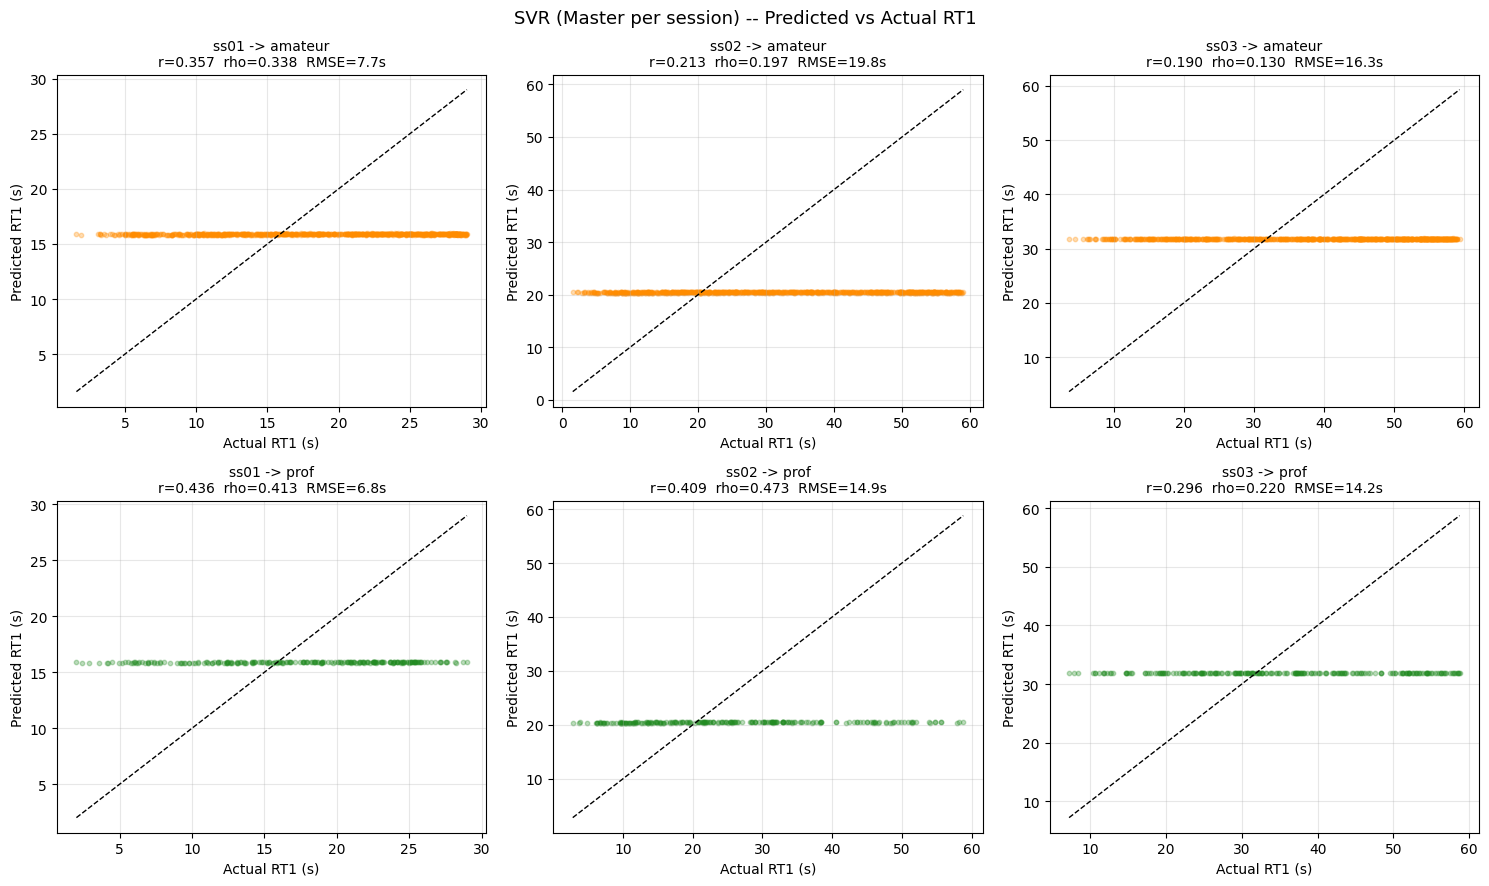

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
COLORS = {'amateur': 'darkorange', 'prof': 'forestgreen'}

for col, ss in enumerate(SESSIONS):
    for row, name in enumerate(['amateur', 'prof']):
        r = results_ss[ss][name]
        ax = axes[row, col]
        ax.scatter(r['y_true'] / 1000, r['y_pred'] / 1000,
                   alpha=0.3, s=10, color=COLORS[name])
        lo = min(r['y_true'].min(), r['y_pred'].min()) / 1000
        hi = max(r['y_true'].max(), r['y_pred'].max()) / 1000
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_title(
            f'{ss} -> {name}\n'
            f'r={r["pearson"]:.3f}  rho={r["spearman"]:.3f}  RMSE={r["rmse"]/1000:.1f}s',
            fontsize=10
        )
        ax.set_xlabel('Actual RT1 (s)')
        ax.set_ylabel('Predicted RT1 (s)')
        ax.grid(alpha=0.3)

plt.suptitle('SVR (Master per session) -- Predicted vs Actual RT1', fontsize=13)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\svr_rt_per_session.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── 各 Subject 平均預測誤差（Subject-level 分析）──
def subject_level_report(name, X_raw, y_true_s, y_pred):
    sub_idx = X_raw.index.get_level_values('SubjectID')
    rows = []
    for sub in np.unique(sub_idx):
        mask = sub_idx == sub
        yt = y_true_s[mask]
        yp = y_pred[mask]
        rows.append({
            'SubjectID': sub,
            'n_trials': mask.sum(),
            'actual_mean': yt.mean(),
            'pred_mean': yp.mean(),
            'MAE': mean_absolute_error(yt, yp),
            'corr': pearsonr(yt, yp)[0] if mask.sum() > 2 else np.nan,
        })
    df_r = pd.DataFrame(rows).set_index('SubjectID')
    print(f'\n=== {name} Subject-level ===' )
    print(df_r.to_string())
    print(f'Mean MAE across subjects: {df_r["MAE"].mean():.1f} ms')
    print(f'Mean within-subject corr: {df_r["corr"].mean():.4f}')
    return df_r

df_amateur = subject_level_report('Amateur', X_amateur, y_amateur.values, pred_amateur)
df_prof    = subject_level_report('Prof',    X_prof,    y_prof.values,    pred_prof)


=== Amateur Subject-level ===
           n_trials   actual_mean     pred_mean           MAE      corr
SubjectID                                                              
sub-21           60  34231.700000  22253.263947  12856.623620  0.420146
sub-22           90  35451.222222  22279.172190  15700.910714  0.060064
sub-23           90  37150.466667  22193.928810  16332.267302 -0.115052
sub-24           89  25079.078652  22208.453791  13636.119098  0.170562
sub-38           90  21646.044444  22234.056584   9656.477795  0.521017
sub-39           90  26630.688889  22202.165428  12115.673004  0.032848
sub-40           90  21683.800000  22187.884099  14002.723596  0.694358
sub-41           90  27449.244444  22216.337116  10587.911601  0.376146
sub-42           90  29004.733333  22239.002850  11950.273926  0.024896
sub-43           90  35608.822222  22244.446556  17464.879261  0.110059
sub-44           90  36195.911111  22218.099692  15167.524078 -0.027547
sub-45           90  39254.844444